In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi, assign_roles
import Soccer_OCEL.utils as utils
import Soccer_OCEL.soccer_plot as plot
import Soccer_OCEL.trajectory_clustering as tc

import geopandas as gpd
import shapely.geometry as geometries
from Soccer_OCEL.soccer_plot import plot_background_ax, fastplot, plot_background, plot_trace, add_legend, add_event

from shapely.geometry import Polygon, LineString, Point
import matplotlib.pyplot as plt

import pm4py
from pm4py.algo.evaluation import algorithm as general_evaluation
from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types

import os
os.environ["PATH"] += ":/opt/homebrew/bin"

In [15]:
path='data/28196177'
#games=['J03WR9']
games=['J03WQQ','J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
GDs=[]
all_flagged=[]
teams=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
    GameData.assign_roles_multi(team=True)
    GameData.format_log('ALL')
    unique_pairs = GameData.team_sheets_df[['team', 'tID', 'Home_Away']].drop_duplicates()
    unique_pairs['Game']=Game
    teams.append(unique_pairs)
    print(unique_pairs)
    GDs.append(GameData.events)
    flagged=pd.read_csv(os.path.join('output','output_cluster',f"{Game}.csv"))
    all_flagged.append(flagged)

allgame_df=pd.concat(GDs).sort_values(['attribute:game','attribute:session','attribute:frame']).reset_index(drop=True)
all_flagged=pd.concat(all_flagged, ignore_index=True)
# GameData=assign_roles(GameData, process_DF='TEAMSHEET')

                 team             tID Home_Away    Game
0  Fortuna Düsseldorf  DFL-CLU-00000P      Home  J03WQQ
0        FC St. Pauli  DFL-CLU-00000H      Away  J03WQQ
                   team             tID Home_Away    Game
0    Fortuna Düsseldorf  DFL-CLU-00000P      Home  J03WR9
0  1. FC Kaiserslautern  DFL-CLU-00000I      Away  J03WR9
                 team             tID Home_Away    Game
0  Fortuna Düsseldorf  DFL-CLU-00000P      Home  J03WPY
0      1. FC Nürnberg  DFL-CLU-000005      Away  J03WPY
                  team             tID Home_Away    Game
0   Fortuna Düsseldorf  DFL-CLU-00000P      Home  J03WOH
0  SSV Jahn Regensburg  DFL-CLU-000011      Away  J03WOH
                 team             tID Home_Away    Game
0  Fortuna Düsseldorf  DFL-CLU-00000P      Home  J03WOY
0  F.C. Hansa Rostock  DFL-CLU-00000Q      Away  J03WOY


In [16]:
unique_pairs = pd.concat(teams, ignore_index=True)
unique_pairs

,team,tID,Home_Away,Game
0,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WQQ
1,FC St. Pauli,DFL-CLU-00000H,Away,J03WQQ
2,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WR9
3,1. FC Kaiserslautern,DFL-CLU-00000I,Away,J03WR9
4,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WPY
5,1. FC Nürnberg,DFL-CLU-000005,Away,J03WPY
6,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WOH
7,SSV Jahn Regensburg,DFL-CLU-000011,Away,J03WOH
8,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WOY
9,F.C. Hansa Rostock,DFL-CLU-00000Q,Away,J03WOY


In [20]:
from pm4py.algo.label_splitting import algorithm as label_splitter
allgame_df = label_splitter.apply(allgame_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})

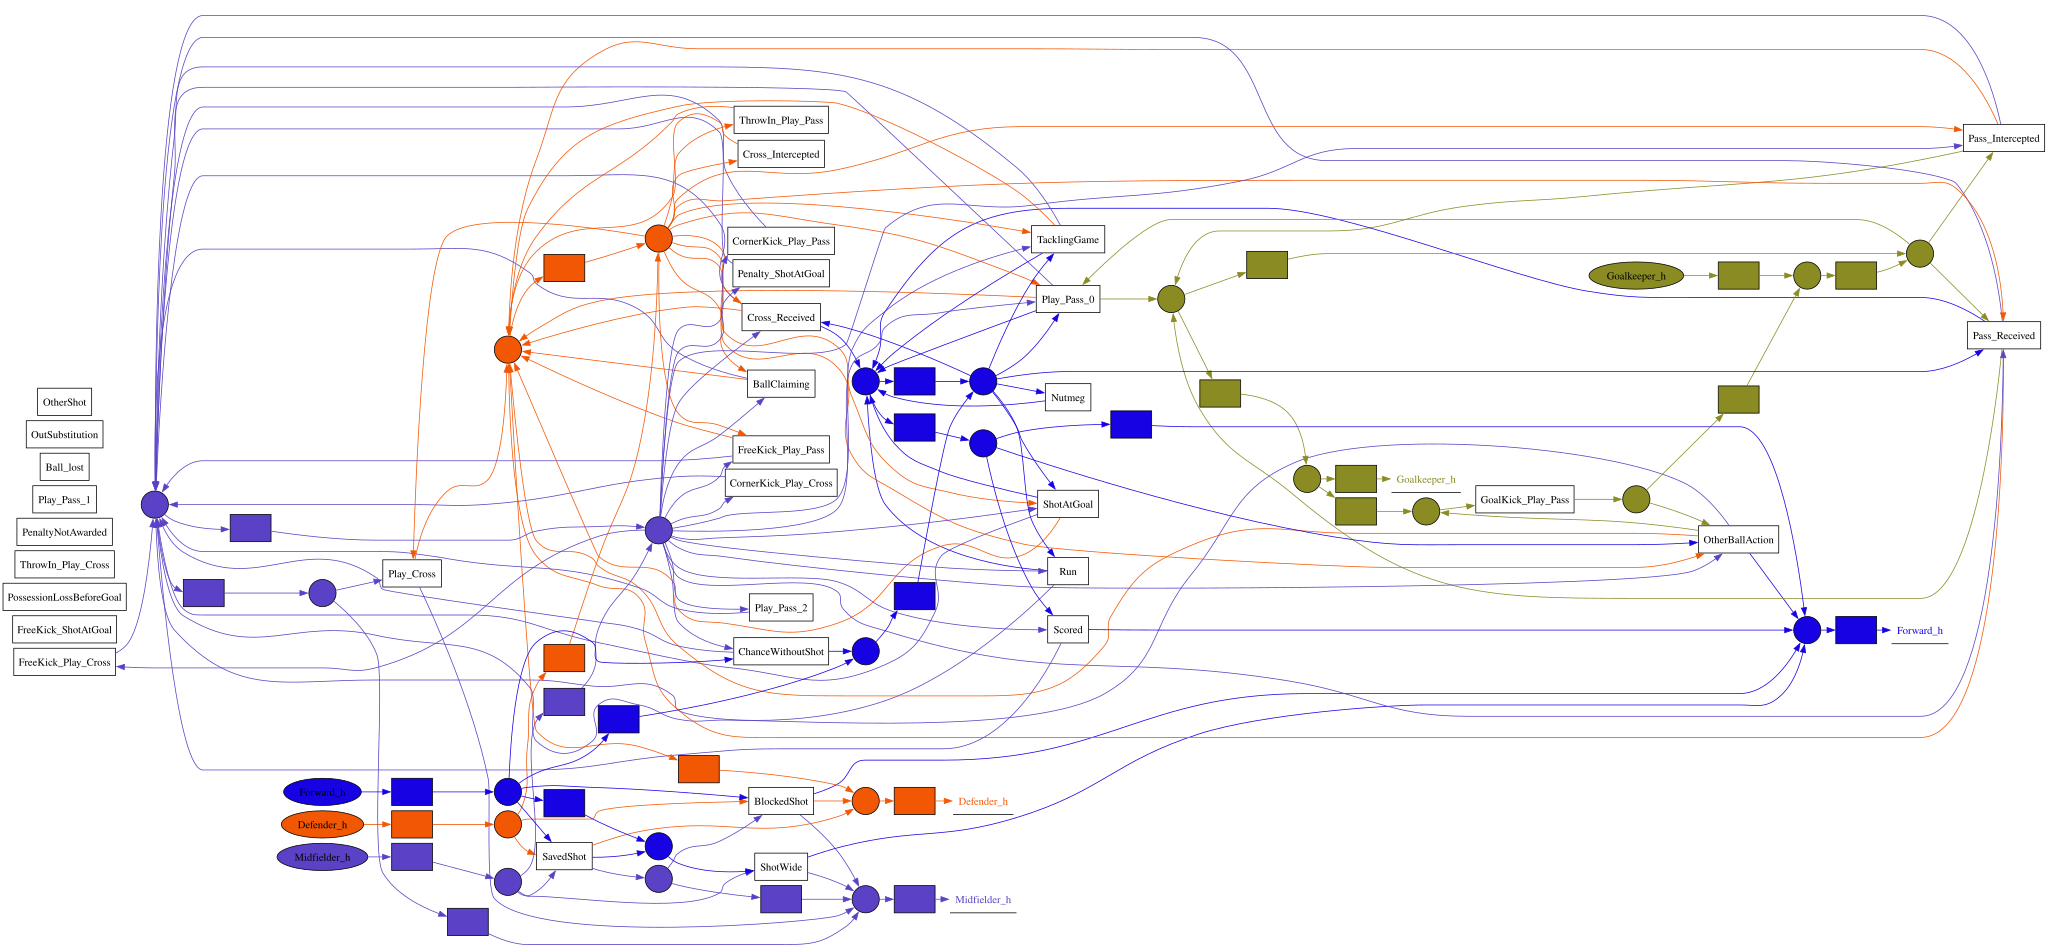

In [29]:
# convert to ocel
#df = allgame_df[allgame_df['case:concept:name'].str.contains('Home', na=False)]
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))&(allgame_df['case:concept:name'].str.contains('Home'))]
df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
initial_log = pm4py.convert_to_event_log(df)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

In [33]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))&(allgame_df['case:concept:name'].str.contains('Away'))]
df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]

FC St. Pauli


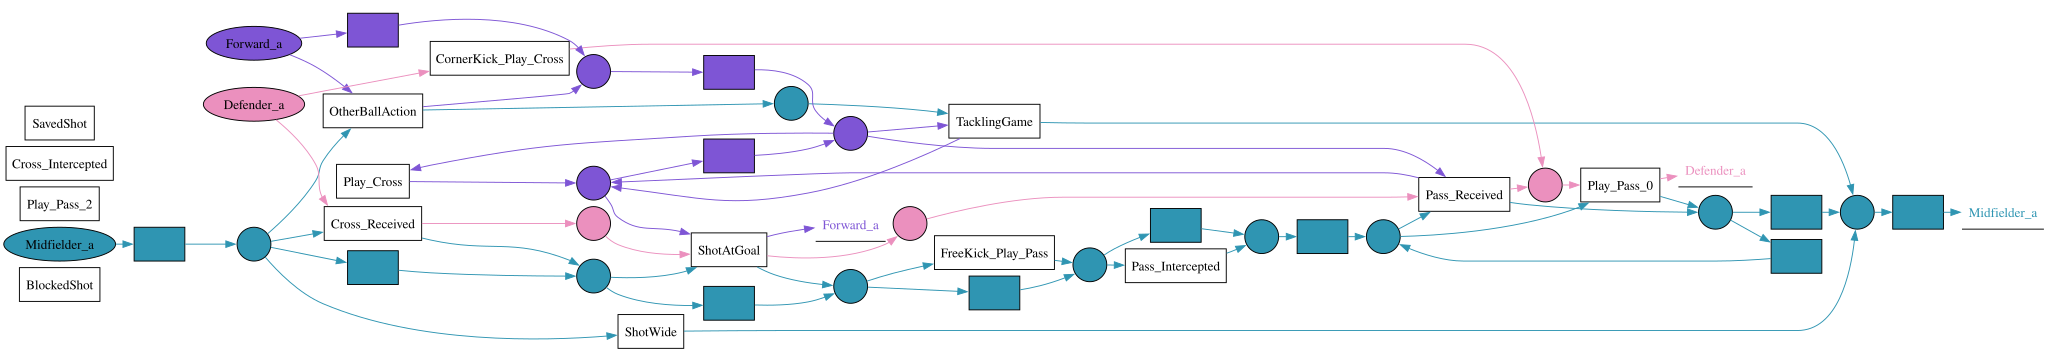

In [47]:
i=0
print(unique_pairs.query('Home_Away=="Away"').iloc[i]['team'])
tdf = df[df['case:concept:name'].str.contains(games[i], na=False)]
initial_log = pm4py.convert_to_event_log(tdf)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                    #'attacking_team', 'defending_team'
                                                    #'ball',
                                                    "Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                    #,'Team','Player','Session', 'case:concept:name'
                                                    ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

1. FC Kaiserslautern


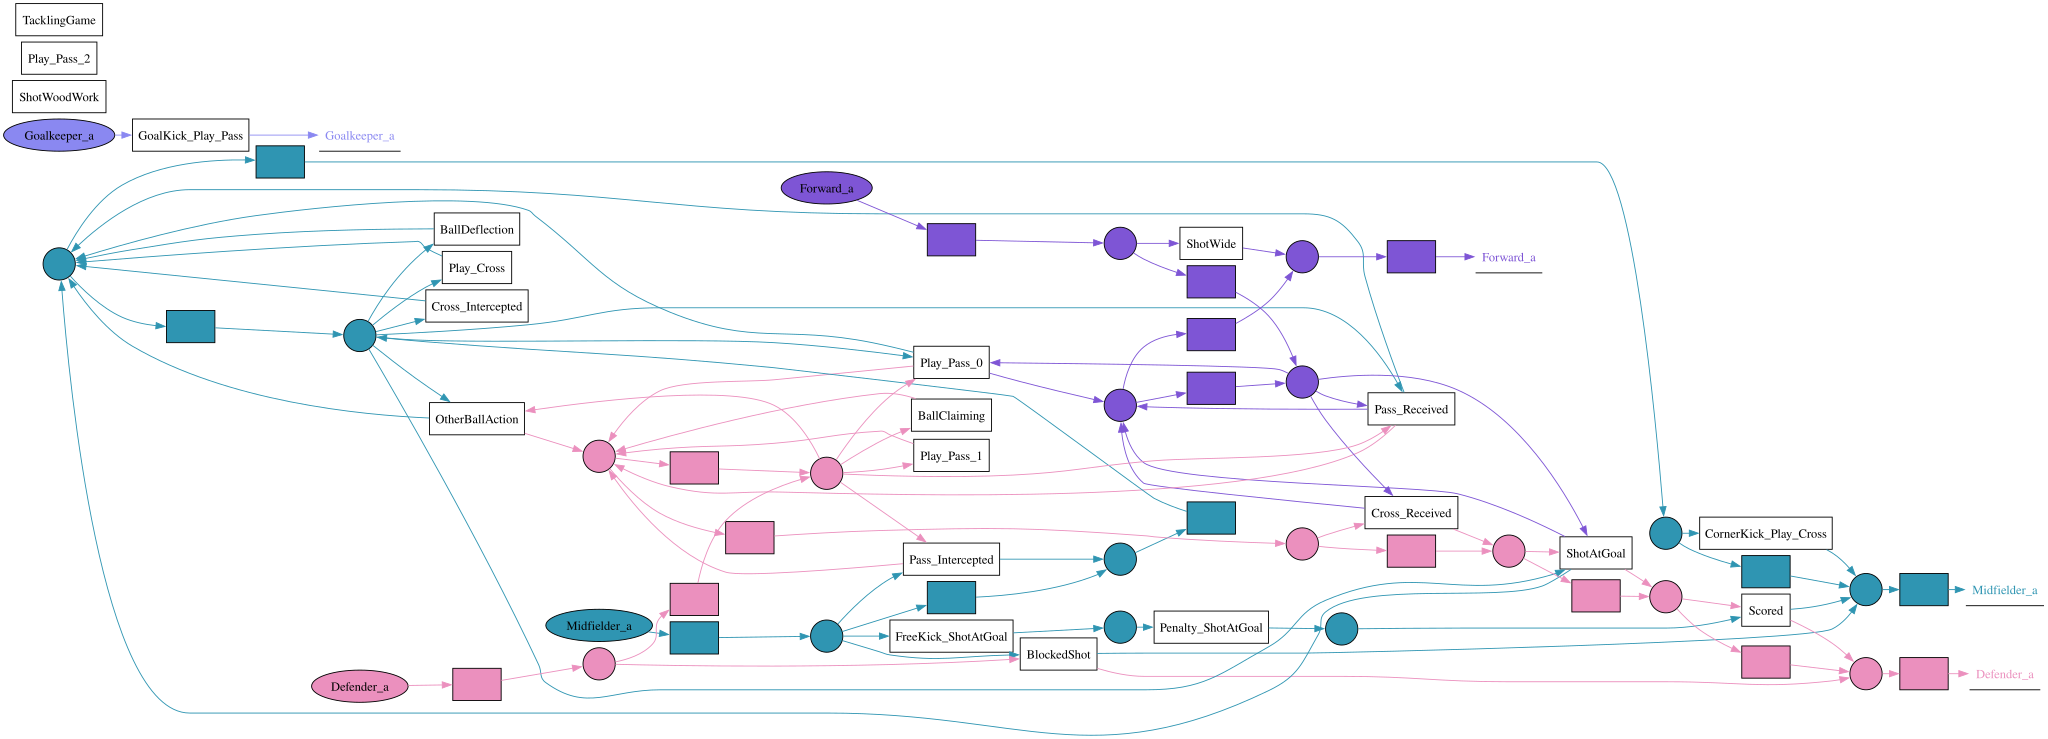

In [48]:
i=1
print(unique_pairs.query('Home_Away=="Away"').iloc[i]['team'])
tdf = df[df['case:concept:name'].str.contains(games[i], na=False)]
initial_log = pm4py.convert_to_event_log(tdf)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                    #'attacking_team', 'defending_team'
                                                    #'ball',
                                                    "Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                    #,'Team','Player','Session', 'case:concept:name'
                                                    ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

1. FC Nürnberg


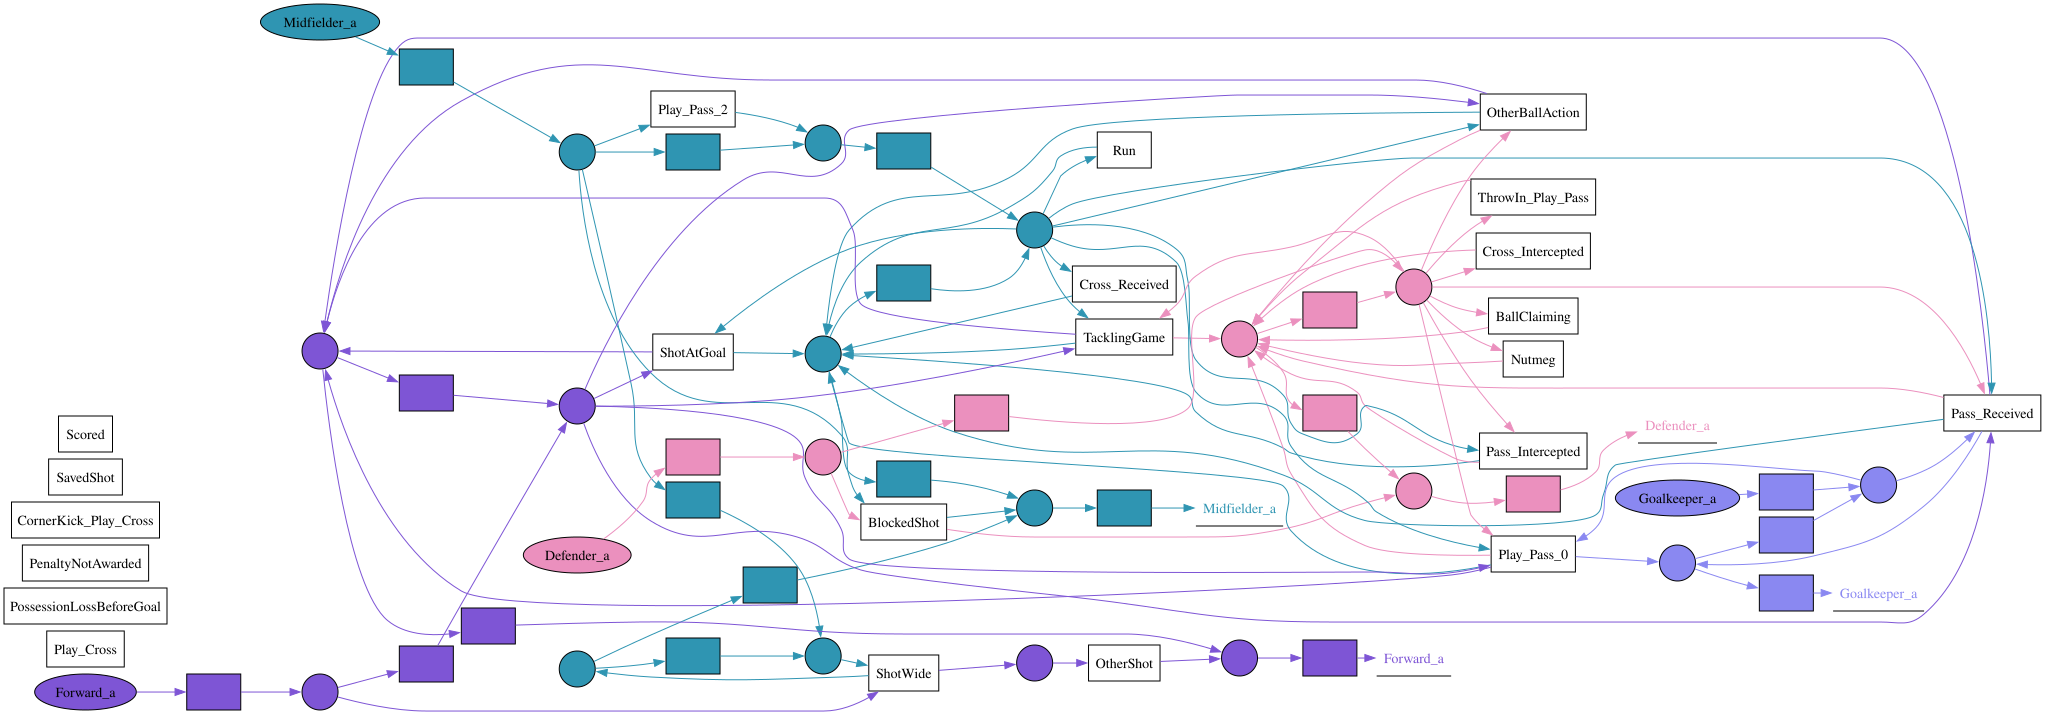

In [49]:
i=2
print(unique_pairs.query('Home_Away=="Away"').iloc[i]['team'])
tdf = df[df['case:concept:name'].str.contains(games[i], na=False)]
initial_log = pm4py.convert_to_event_log(tdf)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                    #'attacking_team', 'defending_team'
                                                    #'ball',
                                                    "Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                    #,'Team','Player','Session', 'case:concept:name'
                                                    ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

SSV Jahn Regensburg


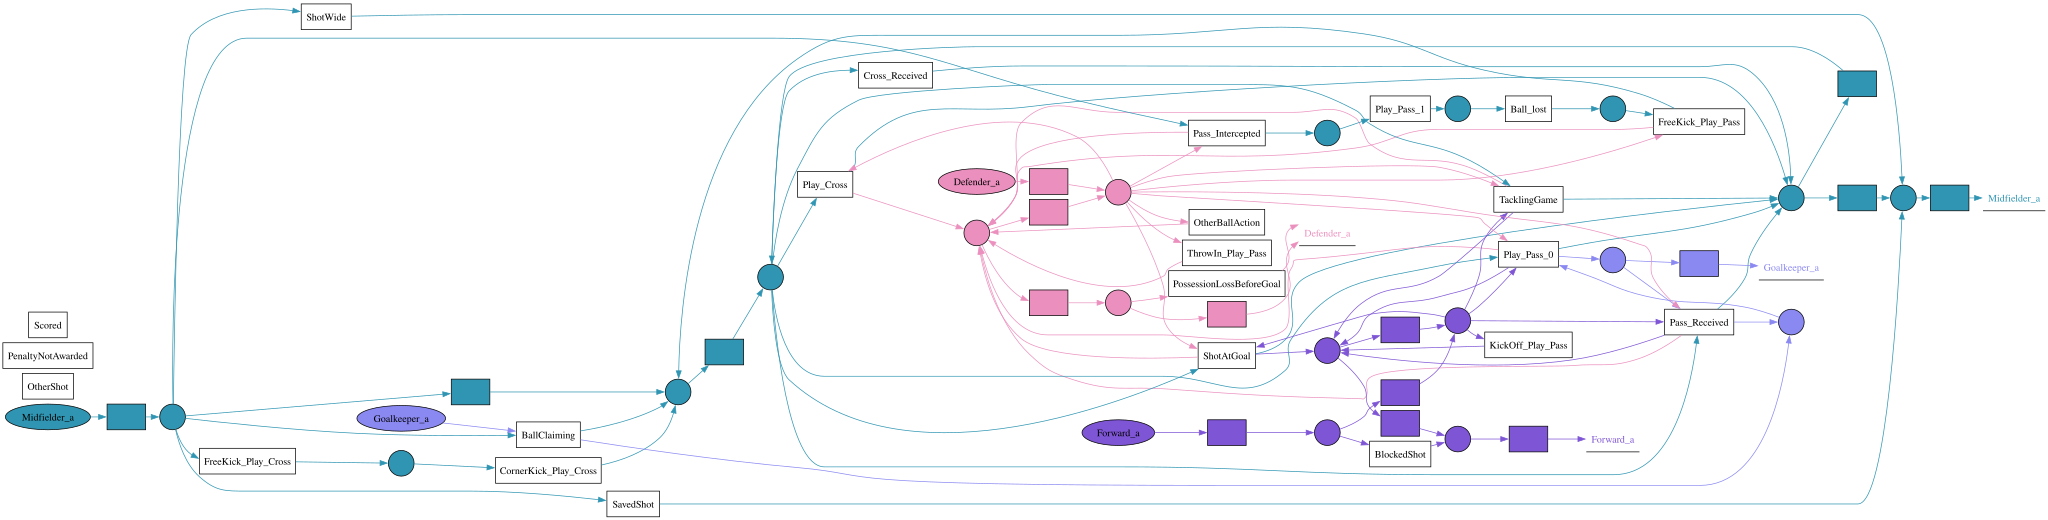

In [50]:
i=3
print(unique_pairs.query('Home_Away=="Away"').iloc[i]['team'])
tdf = df[df['case:concept:name'].str.contains(games[i], na=False)]
initial_log = pm4py.convert_to_event_log(tdf)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                    #'attacking_team', 'defending_team'
                                                    #'ball',
                                                    "Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                    #,'Team','Player','Session', 'case:concept:name'
                                                    ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

F.C. Hansa Rostock


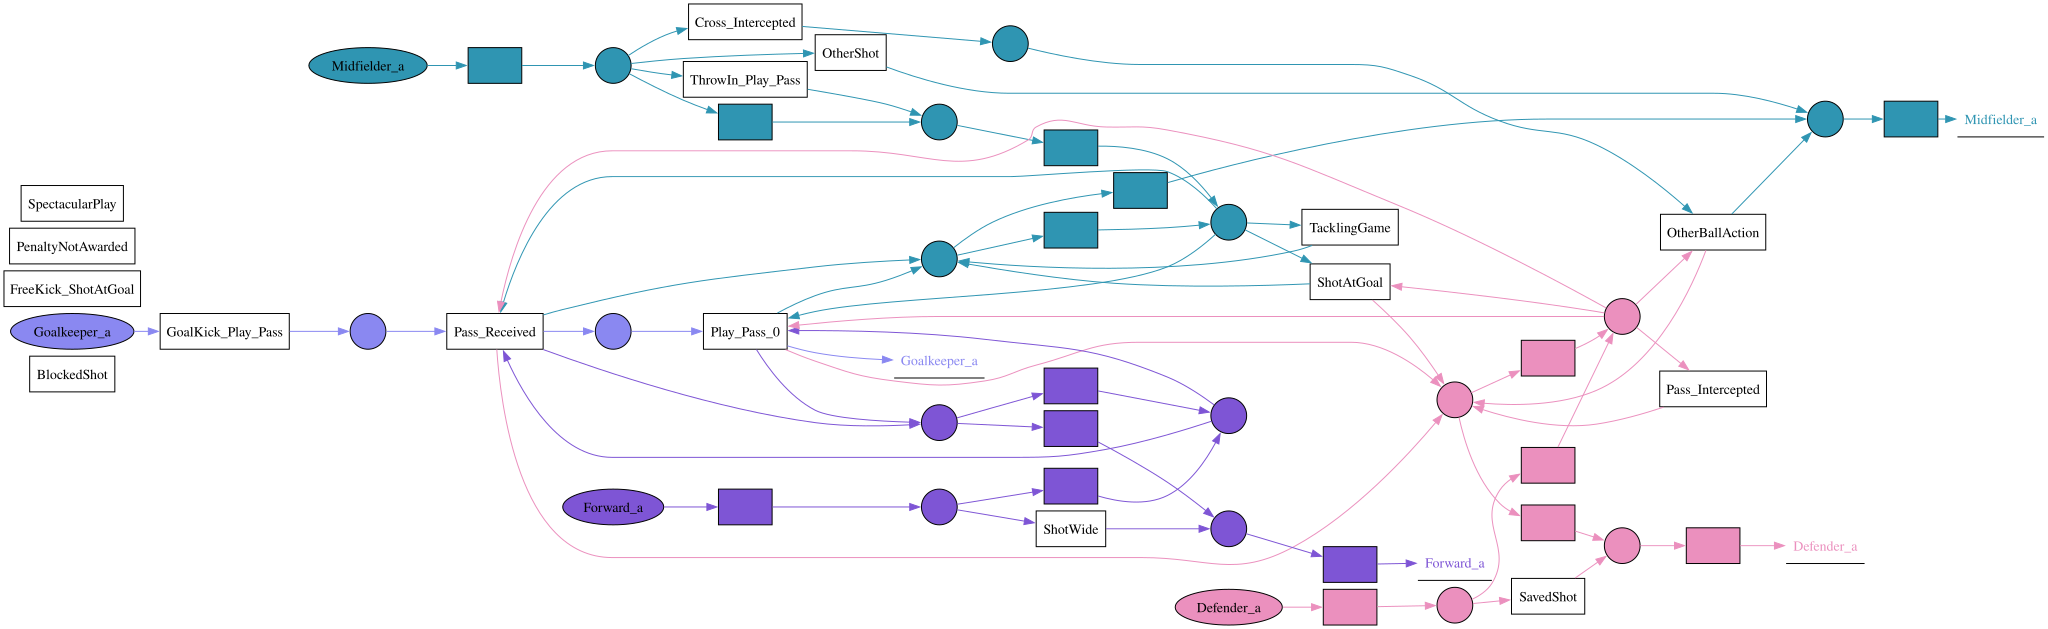

In [51]:
i=4
print(unique_pairs.query('Home_Away=="Away"').iloc[i]['team'])
tdf = df[df['case:concept:name'].str.contains(games[i], na=False)]
initial_log = pm4py.convert_to_event_log(tdf)
ocel= log_to_ocel_multiple_obj_types(initial_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                    #'attacking_team', 'defending_team'
                                                    #'ball',
                                                    "Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                    #,'Team','Player','Session', 'case:concept:name'
                                                    ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
ocpn=pm4py.algo.discovery.ocel.ocpn.algorithm.apply(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(ocpn)

In [53]:
unique_pairs

,team,tID,Home_Away,Game
0,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WQQ
1,FC St. Pauli,DFL-CLU-00000H,Away,J03WQQ
2,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WR9
3,1. FC Kaiserslautern,DFL-CLU-00000I,Away,J03WR9
4,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WPY
5,1. FC Nürnberg,DFL-CLU-000005,Away,J03WPY
6,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WOH
7,SSV Jahn Regensburg,DFL-CLU-000011,Away,J03WOH
8,Fortuna Düsseldorf,DFL-CLU-00000P,Home,J03WOY
9,F.C. Hansa Rostock,DFL-CLU-00000Q,Away,J03WOY


In [31]:
df['case:concept:name']

11         J03WOH_Away_2
12         J03WOH_Away_2
13         J03WOH_Away_2
14         J03WOH_Away_2
16         J03WOH_Away_4
              ...       
11717    J03WR9_Away_221
11943    J03WR9_Away_253
11944    J03WR9_Away_253
12326    J03WR9_Away_314
12327    J03WR9_Away_314
Name: case:concept:name, Length: 563, dtype: object